# Amperon Data Engineering Take Home Assignment

This notebook analyzes weather data scraped from Tomorrow.io API for 10 locations in South Texas.

## Setup

Import required libraries and establish database connection.

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
from sqlalchemy import create_engine
import os

# Set plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)

print("Libraries imported successfully!")

Libraries imported successfully!


In [7]:
# Database connection parameters
DB_HOST = os.getenv('PGHOST', 'postgres')
DB_PORT = os.getenv('PGPORT', '5432')
DB_NAME = os.getenv('PGDATABASE', 'tomorrow')
DB_USER = os.getenv('PGUSER', 'postgres')
DB_PASSWORD = os.getenv('PGPASSWORD', 'postgres')

# Create SQLAlchemy engine
connection_string = f'postgresql://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}'
engine = create_engine(connection_string)

# Test connection
try:
    with engine.connect() as conn:
        print("✓ Successfully connected to PostgreSQL database")
except Exception as e:
    print(f"✗ Failed to connect: {e}")

✓ Successfully connected to PostgreSQL database


---

## Question 1: Latest Temperature and Wind Speed for Each Location

Query the most recent temperature and wind speed readings for all 10 geolocations.

In [8]:
# SQL Query: Latest temperature and wind speed for each location
# Note: Using only recent_history to get actual observations, not forecasts
query_q1 = """
SELECT DISTINCT ON (latitude, longitude)
    latitude,
    longitude,
    temperature,
    wind_speed,
    timestamp,
    data_type
FROM weather_data
WHERE data_type = 'recent_history'
ORDER BY latitude, longitude, timestamp DESC;
"""

# Execute query using SQLAlchemy engine
df_latest = pd.read_sql_query(query_q1, engine)

# Display results
print(f"\n📍 Latest Weather Data for {len(df_latest)} Locations")
print(f"   (Using actual observations from recent_history)")
print("=" * 80)
df_latest


📍 Latest Weather Data for 10 Locations
   (Using actual observations from recent_history)


,latitude,longitude,temperature,wind_speed,timestamp,data_type
0,25.86,-97.42,15.09,2.7,2026-02-09 09:00:00+00:00,recent_history
1,25.90,-97.52,15.25,2.4,2026-02-09 09:00:00+00:00,recent_history
2,25.90,-97.48,15.20,2.4,2026-02-09 09:00:00+00:00,recent_history
3,25.90,-97.44,15.17,2.5,2026-02-09 09:00:00+00:00,recent_history
4,25.90,-97.40,15.02,2.6,2026-02-09 09:00:00+00:00,recent_history
5,25.92,-97.38,15.02,2.5,2026-02-09 09:00:00+00:00,recent_history
6,25.94,-97.54,15.06,2.6,2026-02-09 09:00:00+00:00,recent_history
7,25.94,-97.52,15.26,2.4,2026-02-09 09:00:00+00:00,recent_history
8,25.94,-97.48,15.25,2.3,2026-02-09 09:00:00+00:00,recent_history
9,25.94,-97.44,15.23,2.2,2026-02-09 09:00:00+00:00,recent_history


---

## Question 2: Hourly Time Series (1 Day Ago to 5 Days Future)

Show hourly time series of temperature and other weather variables from 1 day ago to 5 days in the future for location (25.86, -97.42) - South Texas, near Brownsville.

In [9]:
# Select first location for detailed analysis
selected_lat = df_latest.iloc[0]['latitude']
selected_lon = df_latest.iloc[0]['longitude']

print(f"\n🎯 Selected Location: ({selected_lat}, {selected_lon})")
print(f"   South Texas, near Brownsville")

# SQL Query: Temperature time series with seamless transition from history to forecast
# History: Last 24 hours of actual observations
# Forecast: Next 5 days of hourly predictions, starting where history ends
query_q2 = """
WITH history_range AS (
    SELECT 
        MAX(timestamp) as max_history_time
    FROM weather_data
    WHERE 
        latitude = %(lat)s
        AND longitude = %(lon)s
        AND data_type = 'recent_history'
        AND timestamp >= NOW() - INTERVAL '1 day'
)
SELECT
    timestamp,
    temperature,
    'recent_history' as data_type
FROM weather_data
WHERE
    latitude = %(lat)s
    AND longitude = %(lon)s
    AND data_type = 'recent_history'
    AND timestamp >= NOW() - INTERVAL '1 day'

UNION ALL

SELECT
    timestamp,
    temperature,
    'forecast' as data_type
FROM weather_data, history_range
WHERE
    latitude = %(lat)s
    AND longitude = %(lon)s
    AND data_type = 'forecast'
    AND timestamp >= history_range.max_history_time
    AND timestamp <= NOW() + INTERVAL '5 days'

ORDER BY timestamp;
"""

# Execute query using SQLAlchemy engine
df_timeseries = pd.read_sql_query(query_q2, engine, params={'lat': selected_lat, 'lon': selected_lon})

# Convert timestamp to datetime
df_timeseries['timestamp'] = pd.to_datetime(df_timeseries['timestamp'])

# Create separate dataframes for plotting (filtered in SQL, separated here for visualization)
df_history = df_timeseries[df_timeseries['data_type'] == 'recent_history']
df_forecast = df_timeseries[df_timeseries['data_type'] == 'forecast']

print(f"\n📈 Retrieved {len(df_timeseries)} hourly temperature records")
print(f"   Time range: {df_timeseries['timestamp'].min()} to {df_timeseries['timestamp'].max()}")
print(f"\n   History records (last 24h): {len(df_history)}")
print(f"   Forecast records (next 5 days): {len(df_forecast)}")
if len(df_history) > 0:
    print(f"   History ends at: {df_history['timestamp'].max()}")
if len(df_forecast) > 0:
    print(f"   Forecast starts at: {df_forecast['timestamp'].min()}")


🎯 Selected Location: (25.86, -97.42)
   South Texas, near Brownsville

📈 Retrieved 141 hourly temperature records
   Time range: 2026-02-08 13:00:00+00:00 to 2026-02-14 08:00:00+00:00

   History records (last 24h): 21
   Forecast records (next 5 days): 120
   History ends at: 2026-02-09 09:00:00+00:00
   Forecast starts at: 2026-02-09 09:00:00+00:00


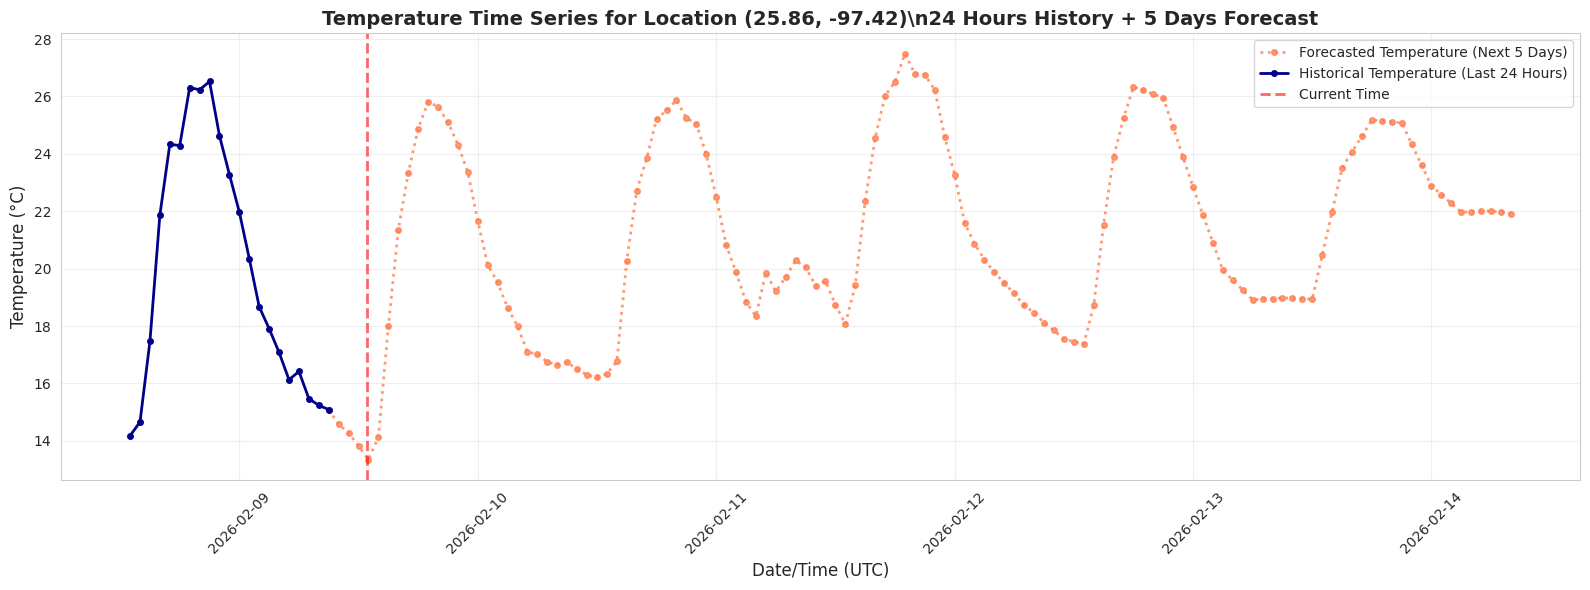

In [10]:
# Temperature Time Series: Historical Observations + Forecast Predictions
fig, ax = plt.subplots(figsize=(16, 6))

# Plot forecast first (background), then history on top (foreground)
# This ensures the historical line remains visible
ax.plot(df_forecast['timestamp'], df_forecast['temperature'], 
        marker='o', linewidth=2, markersize=4, color='coral', linestyle=':', 
        label='Forecasted Temperature (Next 5 Days)', alpha=0.8)

ax.plot(df_history['timestamp'], df_history['temperature'], 
        marker='o', linewidth=2, markersize=4, color='darkblue', linestyle='-', 
        label='Historical Temperature (Last 24 Hours)')

# Add vertical line marking current time
now = pd.Timestamp.now(tz='UTC')
ax.axvline(now, color='red', linestyle='--', linewidth=2, label='Current Time', alpha=0.6)

# Chart formatting
ax.set_xlabel('Date/Time (UTC)', fontsize=12)
ax.set_ylabel('Temperature (°C)', fontsize=12)
ax.set_title(f'Temperature Time Series for Location ({selected_lat}, {selected_lon})\\n24 Hours History + 5 Days Forecast', 
             fontsize=14, fontweight='bold')
ax.legend(loc='best', fontsize=10)
ax.grid(alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

---

## Conclusion

This notebook successfully demonstrates:

1. ✅ **Latest weather data** for all 10 geolocations with temperature and wind speed (using actual observations from recent_history only)
2. ✅ **Hourly time series visualization** spanning from 1 day ago to 5 days in the future for location (25.86, -97.42)

**SQL-First Approach**: The analysis uses SQL UNION to combine historical observations and forecast predictions in a single query, leveraging the database for efficient data retrieval before visualization in Python.